# 00 · Configuración y fuentes locales

Este cuaderno implementa la **fase A** del plan: configuración, entorno, manifiesto,
lectores, catálogo y pendientes. Su objetivo es dejar las fuentes accesibles y trazables
para `01_indicios_limpieza_etiquetas`.

Trabajamos exclusivamente con los archivos descargados. Los servicios de QGIS se
registran como referencias; **no se realiza ninguna descarga de datos**. Las fuentes se
abren en lectura y los informes se escriben en `reports/fase_a/<ejecución>/`.

Una capa cargada no significa una capa limpia: conservamos CRS, atributos, máscaras y
valores originales. No se aplica todavía reproyección, imputación, deduplicación,
construcción del target ni entrenamiento de Random Forest.

**Cómo ejecutarlo en VS Code:** selecciona el intérprete
`Proyecto Con Luis/.venv-fase-a/Scripts/python.exe` y pulsa **Ejecutar todo**.
En otra máquina, desde la raíz del proyecto:

```powershell
python -m venv .venv-fase-a
.\.venv-fase-a\Scripts\python.exe -m pip install -r requirements-fase-a.txt
```

El manifiesto SHA-256 lee todos los bytes de las fuentes: la primera ejecución puede
tardar varios minutos. No se cargan simultáneamente todas las geometrías en RAM.

## 1. Localizar el proyecto y verificar el entorno

La raíz se detecta desde el workspace, la carpeta del proyecto o `notebooks/`.
Si abres Jupyter desde otra ubicación, indica `PROJECT_ROOT_OVERRIDE`. No hay rutas
personales incrustadas ni instalaciones automáticas dentro del cuaderno.

In [5]:
from pathlib import Path
import importlib.util
import sys

PROJECT_ROOT_OVERRIDE = None  # Ejemplo: Path(r"D:/Datos/Proyecto Con Luis")
required = ["pandas", "geopandas", "pyogrio", "shapely", "pyproj", "rasterio",
            "openpyxl", "yaml", "matplotlib", "nbformat", "nbclient", "ipykernel"]
missing = [name for name in required if importlib.util.find_spec(name) is None]
if missing:
    raise RuntimeError(f"Faltan dependencias: {missing}. Selecciona .venv-fase-a o instala requirements-fase-a.txt.")

start = Path(PROJECT_ROOT_OVERRIDE or Path.cwd()).resolve()
candidates = [candidate for parent in (start, *start.parents)
              for candidate in (parent, parent / "Proyecto Con Luis")]
ROOT = next((p for p in candidates if (p / "config/project.yaml").is_file()
             and (p / "src/geoau/local_sources.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Indica PROJECT_ROOT_OVERRIDE: no se localiza el proyecto.")
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
import numpy as np
from IPython.display import display
from geoau.local_sources import (
    load_config, local_path, discover_sources, environment_info, inventory, catalog_frame,
    read_table, iter_csv, read_vector, read_raster_preview, read_raster_window,
    write_reports, write_json, verify_unchanged,
)
CONFIG = load_config(ROOT)
pd.set_option("display.max_colwidth", 90)
print("Raíz:", ROOT)
print("Intérprete:", sys.executable)
display(pd.Series(environment_info()["packages"], name="versión").to_frame())

Raíz: C:\Users\Lenovo\Desktop\PROYECTO IA\Proyecto Con Luis
Intérprete: c:\Users\Lenovo\Desktop\PROYECTO IA\Proyecto Con Luis\.venv-fase-a\Scripts\python.exe


,versión
pandas,3.0.5
geopandas,1.1.4
pyogrio,0.13.0
shapely,2.1.2
pyproj,3.8.0
rasterio,1.5.1
openpyxl,3.1.5
PyYAML,6.0.3
nbformat,5.11.1
nbclient,0.11.0


## 2. Especificación y decisiones pendientes

La configuración propone 1 km y EPSG:25830 para el diseño peninsular futuro. No
reproyecta capas ni declara una cobertura nacional validada. El piloto queda pendiente.
El paso 06 del plan se adapta a este encargo local: **registramos qué falta recuperar**.
Los datos adicionales se incorporarán cuando estén disponibles localmente.

In [6]:
display(pd.json_normalize({"scope": CONFIG["scope"], "model_design": CONFIG["model_design"]}).T)
paths = discover_sources(ROOT, CONFIG)
print(f"{len(paths)} archivos locales; {sum(p.stat().st_size for p in paths)/1e9:.2f} GB.")
display(pd.Series([p.suffix.lower() for p in paths]).value_counts().rename_axis("formato").to_frame("archivos"))

,0
scope.final_objective,España
scope.initial_scope,España peninsular; cobertura por verificar
scope.pilot,None
scope.pilot_status,pendiente de revisión geológica y cobertura
model_design.output,indice_de_favorabilidad
model_design.target,presencia Au revisada; territorio no etiquetado U
model_design.geological_targets,"[roca, aluvial, general]"
model_design.proposed_grid_m,1000
model_design.proposed_crs,EPSG:25830
model_design.validation,espacial_por_deposito_y_distrito


93 archivos locales; 6.40 GB.


,archivos
formato,
.gpkg,36
.tif,20
.csv,16
.qmd,8
.xml,5
.qgz,1
.xlsx,1
.zip,1
.cpg,1


## 3. Inventariar, calcular hashes e inspeccionar

Se inspeccionan los archivos fuente de la raíz y la carpeta del shapefile. Se excluyen
entornos, notebooks, informes generados y código: no son nuevas observaciones GIS.
Se cuentan registros por bloques en CSV y mediante SQLite en GPKG. La muestra de
atributos conserva nombres y valores; la validez de geometrías completas sigue pendiente.

SHA-256 identifica exactamente la copia local. La fecha del archivo no se presenta
como fecha de descarga y una licencia desconocida queda sin verificar.

In [7]:
# Lee aproximadamente el volumen total de las fuentes para el hash.
# Para una exploración rápida puedes poner False, pero el manifiesto no quedará congelado por hash.
CONFIG["inspection"]["compute_sha256"] = True
registros = inventory(ROOT, CONFIG)
catalogo = catalog_frame(registros)
display(catalogo[["path", "role", "status", "row_count", "bytes"]])
print("Estado de lectura:")
display(catalogo.groupby("status", dropna=False).size().to_frame("archivos"))

[01/93] AtlasGeoquimico_As_Sedimentos_2012.tif
[02/93] AtlasGeoquimico_As_Sedimentos_2012_RGB.tif
[03/93] AtlasGeoquimico_Au_Sedimentos_2012.tif
[04/93] AtlasGeoquimico_Au_Sedimentos_2012.tif.aux.xml
[05/93] AtlasGeoquimico_Au_Sedimentos_2012_RGB.tif
[06/93] AtlasGeoquimico_Bi_Sedimentos_2012.tif
[07/93] AtlasGeoquimico_Bi_Sedimentos_2012_RGB.tif
[08/93] AtlasGeoquimico_Cu_Sedimentos_2012.tif
[09/93] AtlasGeoquimico_Cu_Sedimentos_2012_RGB.tif
[10/93] AtlasGeoquimico_Hg_Sedimentos_2012.tif
[11/93] AtlasGeoquimico_Hg_Sedimentos_2012_RGB.tif
[12/93] AtlasGeoquimico_Pb_Sedimentos_2012.tif
[13/93] AtlasGeoquimico_Pb_Sedimentos_2012_RGB.tif
[14/93] AtlasGeoquimico_Sb_Sedimentos_2012.tif
[15/93] AtlasGeoquimico_Sb_Sedimentos_2012_RGB.tif
[16/93] AtlasGeoquimico_W_Sedimentos_2012.tif
[17/93] AtlasGeoquimico_W_Sedimentos_2012_RGB.tif
[18/93] AtlasGeoquimico_Zn_Sedimentos_2012.tif
[19/93] AtlasGeoquimico_Zn_Sedimentos_2012_RGB.tif
[20/93] Au.gpkg
[21/93] buzamientos.gpkg
[22/93] Capas.qgz
[23/93

,path,role,status,row_count,bytes
0,AtlasGeoquimico_As_Sedimentos_2012.tif,geoquimica_clasificada,requiere_revision,NaN,739637
1,AtlasGeoquimico_As_Sedimentos_2012_RGB.tif,visual,visual,NaN,405144
2,AtlasGeoquimico_Au_Sedimentos_2012.tif,geoquimica_clasificada,requiere_revision,NaN,803402
3,AtlasGeoquimico_Au_Sedimentos_2012.tif.aux.xml,metadatos_o_componente,registrado,NaN,1498011
4,AtlasGeoquimico_Au_Sedimentos_2012_RGB.tif,visual,visual,NaN,469519
...,...,...,...,...,...
88,red-hidrografica2022_27/red-hidrografica2022-27_marzo2023.prj,metadatos_o_componente,registrado,NaN,147
89,red-hidrografica2022_27/red-hidrografica2022-27_marzo2023.shp,vector_fuente,requiere_revision,13396.0,145625460
90,red-hidrografica2022_27/red-hidrografica2022-27_marzo2023.shx,metadatos_o_componente,registrado,NaN,107268
91,redhidrografica.gpkg,vector_fuente,requiere_revision,13396.0,156913664


Estado de lectura:


,archivos
status,
auxiliar_sin_raster,2
registrado,17
requiere_conciliacion,1
requiere_revision,38
sin_datos,9
tabla_sin_geometria_verificada,16
visual,10


## 4. Fuentes canónicas, archivos vacíos y problemas de lectura

Los alias señalan fuentes **candidatas**, no certificados de calidad. El GPKG de indicios
será la base de trabajo; Excel y CSV se conservan separados para conciliar diferencias.
`contactos_geode` apunta al nombre local real `contactos-002.gpkg`.

In [24]:
por_ruta = {item["path"]: item for item in registros}
fuentes = {alias: local_path(ROOT, name) for alias, name in CONFIG["canonical_candidates"].items()}
canonicas = pd.DataFrame([
    {"alias": alias, "archivo": path.name, "existe": path.is_file(),
     "estado": por_ruta.get(path.relative_to(ROOT).as_posix(), {}).get("status", "ausente")}
    for alias, path in fuentes.items()
])
display(canonicas)
display(catalogo[catalogo.status.isin(["sin_datos", "error", "auxiliar_sin_raster"])][["path", "status", "error"]])
errores_lectura = catalogo[catalogo.status.eq("error")]
print("Errores de lectura:", len(errores_lectura))
print("Los archivos sin datos se catalogan; no se sustituyen por tablas inventadas.")

,alias,archivo,existe,estado
0,indicios,IndiciosII.gpkg,True,requiere_revision
1,litologia,litologias.gpkg,True,requiere_revision
2,edades,edades.gpkg,True,requiere_revision
3,recintos,recintos.gpkg,True,requiere_revision
4,contactos_geode,contactos-002.gpkg,True,requiere_revision
5,estructuras_magna,contactosyfallas.gpkg,True,requiere_revision
6,ejes_geode,ejes.gpkg,True,requiere_revision
7,pliegues_magna,estructuras de plegamiento.gpkg,True,requiere_revision
8,hidrografia,redhidrografica.gpkg,True,requiere_revision
9,relieve,MDT_Espana_CNIG_500m.tif,True,requiere_revision


,path,status,error
20,buzamientos.gpkg,sin_datos,None
30,cuaternariorecintos.gpkg,sin_datos,None
50,gravimetria.gpkg,sin_datos,None
71,magnetometriaradiometria.gpkg,sin_datos,None
72,magnetotelurico.gpkg,sin_datos,None
73,MDT_CNIG_Elevacion_Hillshade_RGB.tif.aux.xml,auxiliar_sin_raster,None
74,MDT_CNIG_Topografia_2012.tif.aux.xml,auxiliar_sin_raster,None
79,medidasestructurales.gpkg,sin_datos,None
80,oro.gpkg,sin_datos,None
81,petrofisica.gpkg,sin_datos,None


Errores de lectura: 0
Los archivos sin datos se catalogan; no se sustituyen por tablas inventadas.


## 5. Cargar los indicios y las tablas de contraste

Aquí sí cargamos las tres fuentes completas, por su tamaño reducido. Los campos
tabulares se leen como texto para conservar códigos y ceros iniciales. No se infieren
tipos químicos ni se convierte `X/Y` en geometría: ese saneamiento pertenece a fase B.

No se concatenan las tres tablas. Los recuentos se calculan sobre los archivos actuales,
no se copian del informe de auditoría.

In [9]:
indicios = read_vector(fuentes["indicios"], max_features=None, allow_full=True)
indicios_csv = read_table(ROOT / "IndiciosII.csv", nrows=None)
indicios_excel = read_table(ROOT / "Indicios.xlsx", nrows=None)
tablas = {"indicios_csv": indicios_csv, "indicios_excel": indicios_excel}
vectores = {"indicios": indicios}

resumen_indicios = pd.DataFrame([
    {"fuente": name, "filas": len(table),
     "codigos_distintos": table["Codigo_indicio"].nunique(),
     "crs_geometria": str(getattr(table, "crs", "No contiene geometría"))}
    for name, table in [("GPKG", indicios), ("CSV", indicios_csv), ("Excel", indicios_excel)]
])
display(resumen_indicios)
display(indicios.head())
display(indicios_csv.head())
print("Primer código CSV:", repr(indicios_csv.iloc[0]["Codigo_indicio"]))

,fuente,filas,codigos_distintos,crs_geometria
0,GPKG,11732,11732,EPSG:4326
1,CSV,11732,10989,No contiene geometría
2,Excel,11732,10141,No contiene geometría


,Codigo_indicio,Nombre_mina,Sustancia,Provincia,Municipio,X,Y,Zona_Geode,Azimut,Edad_inferior,Edad_superior,Asociacion_mineral,Morfologia,Tamaño_indicio,ESRI_OID,geometry
0,0001001,SEIJO,Cuarzo,CORUÑA,Cariño,-7.916255,43.693363,Zona de Galicia Tras-os-Montes,130.0,,,Minerales industriales,Filoniana,desconocido,3061,POINT (-7.91625 43.69336)
1,0001002,DA BARAXIE,Titanio / Rutilo,CORUÑA,Cedeira,-7.981779,43.671185,Zona de Galicia Tras-os-Montes,NaN,,,"Fe, Mn, Ti",Irregular,desconocido,3449,POINT (-7.98178 43.67119)
2,0001003,HERBEIRA,Asbesto,CORUÑA,Cedeira,-7.956094,43.714443,Zona de Galicia Tras-os-Montes,NaN,,,Minerales industriales,Filoniana,desconocido,3450,POINT (-7.95609 43.71444)
3,0001004,COTO AMENEIRO,"Aluminio, Cromo/Cromita, Hierro, Magnesio",CORUÑA,Cedeira,-7.951328,43.717281,Zona de Galicia Tras-os-Montes,NaN,,,"Cr, Ni, Pt, EGP",Irregular,desconocido,3451,POINT (-7.95133 43.71728)
4,0001005,TEIXIDELO,"Cobalto, Cobre, Cromo/Cromita, Niquel",CORUÑA,Cedeira,-7.962816,43.720537,Zona de Galicia Tras-os-Montes,NaN,,,"Co, Ni, Bi, Ag",Desconocida,desconocido,2265,POINT (-7.96282 43.72054)


,Codigo_indicio,Nombre_mina,Sustancia,Provincia,Municipio,X,Y,Zona_Geode,Azimut,Edad_inferior,Edad_superior,Asociacion_mineral,Morfologia,Tamaño_indicio,ESRI_OID
0,0001001,SEIJO,Cuarzo,CORUÑA,Cariño,-7.91625461,43.69336299,Zona de Galicia Tras-os-Montes,130,,,Minerales industriales,Filoniana,desconocido,3061
1,0001002,DA BARAXIE,Titanio / Rutilo,CORUÑA,Cedeira,-7.9817791,43.67118547,Zona de Galicia Tras-os-Montes,,,,"Fe, Mn, Ti",Irregular,desconocido,3449
2,0001003,HERBEIRA,Asbesto,CORUÑA,Cedeira,-7.9560943,43.71444337,Zona de Galicia Tras-os-Montes,,,,Minerales industriales,Filoniana,desconocido,3450
3,0001004,COTO AMENEIRO,"Aluminio, Cromo/Cromita, Hierro, Magnesio",CORUÑA,Cedeira,-7.95132756,43.71728099,Zona de Galicia Tras-os-Montes,,,,"Cr, Ni, Pt, EGP",Irregular,desconocido,3451
4,0001005,TEIXIDELO,"Cobalto, Cobre, Cromo/Cromita, Niquel",CORUÑA,Cedeira,-7.96281649,43.72053731,Zona de Galicia Tras-os-Montes,,,,"Co, Ni, Bi, Ag",Desconocida,desconocido,2265


Primer código CSV: '0001001'


## 6. Cargar vectores canónicos con límites de memoria

Litología y edades se cargan completas. Recintos, contactos, fallas, pliegues y red
hidrográfica se muestran con lectura acotada. El catálogo permite acceder a todas las
capas internas; no se omiten los GPKG que no son canónicos.

Las capas con curvas se previsualizan como atributos. La prueba geoespacial siguiente
autoriza su conversión únicamente para comprobar compatibilidad de lectura.

In [10]:
for alias in ("litologia", "edades"):
    record = por_ruta[fuentes[alias].relative_to(ROOT).as_posix()]
    if record.get("row_count", 0) > CONFIG["inspection"]["max_full_vector_features"]:
        raise RuntimeError(f"{alias}: supera el límite de carga completa; utilizar muestra o bbox.")
    vectores[alias] = read_vector(fuentes[alias], max_features=None, allow_full=True)

muestras_vectores = {}
for record in registros:
    if record["format"] != ".gpkg" or record["status"] in ("sin_datos", "error"):
        continue
    for layer in record["details"]["layers"]:
        key = record["path"] + "|" + layer["table_name"]
        muestras_vectores[key] = read_vector(local_path(ROOT, record["path"]),
                                             layer=layer["table_name"], max_features=5,
                                             read_geometry=False)
hidrografia_muestra = read_vector(fuentes["hidrografia"], max_features=100)
print("Vectores completos:", {key: len(value) for key, value in vectores.items()})
print("Capas internas con muestra de atributos:", len(muestras_vectores))
display(vectores["litologia"].head())
display(hidrografia_muestra.head())

c:\Users\Lenovo\Desktop\PROYECTO IA\Proyecto Con Luis\.venv-fase-a\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(


Vectores completos: {'indicios': 11732, 'litologia': 16007, 'edades': 16007}
Capas internas con muestra de atributos: 27


,OBJECTID,Id,Litologia,geometry
0,1,12,Otros granitoides,"MULTIPOLYGON (((-853771.636 5428869.594, -855071.857 5430057.943, -856068.216 5431983...."
1,2,7,Granitoides de dos micas,"MULTIPOLYGON (((-853771.636 5428869.594, -854172.072 5428570.748, -854296.761 5428286...."
2,3,21,Serpentinitas y peridotitas. Rocas básicas y ultrabásicas,"MULTIPOLYGON (((-875507.567 5428742.649, -875944.396 5427312.671, -876842.68 5424413.0..."
3,4,22,"Micaesquistos, filitas, areniscas, mármoles, calizas, dolomías y margas","MULTIPOLYGON (((-875823.773 5424129.302, -875871.329 5424142.442, -876842.68 5424413.0..."
4,5,54,"Cuarcitas, pizarras, areniscas y calizas","MULTIPOLYGON (((-857881.654 5429080.45, -856707.242 5427340.177, -857256.777 5426605.4..."


,thematicId,themaIdSch,hydroId,namespace,geonameTxt,geonamTxtL,continua,geometry
0,ES010MSPFES372MAR000010,euSurfaceWaterBodyCode,1,http://www.chminosil.es,Río Miño,spa,realSurfaceWaterSegment,"MULTILINESTRING ((-7.2785 43.20963, -7.27854 43.20964, -7.27857 43.20965, -7.27861 43...."
1,ES010MSPFES372MAR000052,euSurfaceWaterBodyCode,10,http://www.chminosil.es,Río Miño,spa,realSurfaceWaterSegment,"MULTILINESTRING ((-7.38503 43.26361, -7.38505 43.26363, -7.38507 43.26365, -7.38509 43..."
2,ES010MSPFES393MAR000240,euSurfaceWaterBodyCode,100,http://www.chminosil.es,Río de Busto,spa,realSurfaceWaterSegment,"MULTILINESTRING ((-7.17598 42.93596, -7.17602 42.93596, -7.17611 42.93595, -7.17615 42..."
3,ES010MSPFES464MAR001671,euSurfaceWaterBodyCode,100013406,http://www.chminosil.es,Río Mao,spa,realSurfaceWaterSegment,"MULTILINESTRING ((-7.46896 42.57604, -7.46901 42.57586, -7.46902 42.57584, -7.46903 42..."
4,ES010MSPFES494MAR002260,euSurfaceWaterBodyCode,100013417,http://www.chminosil.es,Río Miño,spa,realSurfaceWaterSegment,"MULTILINESTRING ((-8.19339 42.15554, -8.19421 42.15515, -8.19504 42.15485, -8.19538 42..."


In [11]:
display(muestras_vectores)

{'Au.gpkg|isocontenidos_oro_sedimentos_2012':    clase_id     rango_ppb  au_min_ppb  au_max_ppb  au_mid_ppb nivel_anomalia
 0         0   0,08 - 1,34        0.08        1.34        0.33          Fondo
 1         1      1,35 - 2        1.35        2.00        1.64          Fondo
 2         2    2,01 - 3,5        2.01        3.50        2.65          Fondo
 3         3    3,51 - 6,1        3.51        6.10        4.63       Moderada
 4         4  6,11 - 12,05        6.11       12.05        8.58       Moderada,
 'contactos-002.gpkg|contactos':    OBJECTID  ID    GEOM_LEN CODE_LINE                         DESC_LINE  \
 0         1   1  514.767445    540501  Límite político - administrativo   
 1         2   2   99.689785    540501  Límite político - administrativo   
 2         3   3   49.669505    540501  Límite político - administrativo   
 3         4   4   28.710848    550101                             Falla   
 4         5   5  323.876539    551001                     Cabalgamiento  

## 7. Pruebas geoespaciales del entorno

La conversión temporal de coordenadas comprueba la instalación; no reemplaza las
coordenadas originales. Las curvas leídas por GDAL pueden perder M o ser linealizadas:
la advertencia se conserva y el resultado no se usa como capa limpia.

Los filtros espaciales exigen `bbox_crs`, porque las capas locales usan distintos CRS.

In [23]:
from pyproj import Transformer

tr = Transformer.from_crs("EPSG:4326", "EPSG:25830", always_xy=True)
easting, northing = tr.transform(-3.0, 40.0)
assert abs(easting - 500000) < 1
assert 4_400_000 < northing < 4_500_000

curvas_preview = read_vector(fuentes["contactos_geode"], max_features=5,
                             allow_curve_conversion=True)

display(curvas_preview.head())
print("CRS nativo de curvas:", curvas_preview.crs)
print("Geometrías devueltas por GDAL:", curvas_preview.geom_type.unique())
assert len(curvas_preview) > 0 and curvas_preview.crs is not None

# Recorte de demostración; NO fija el piloto del proyecto.
indicios_recorte = read_vector(fuentes["indicios"], bbox=(-7.5, 42.0, -5.0, 43.5),
                               bbox_crs="EPSG:4326", max_features=100)
display(indicios_recorte.head())

C:\Users\Lenovo\Desktop\PROYECTO IA\Proyecto Con Luis\src\geoau\local_sources.py:156: UserWarning: Vista previa de curvas: GDAL puede linealizar y alterar Z/M. No usar como capa armonizada.
  warnings.warn('Vista previa de curvas: GDAL puede linealizar y alterar Z/M. No usar como capa armonizada.', UserWarning)
c:\Users\Lenovo\Desktop\PROYECTO IA\Proyecto Con Luis\.venv-fase-a\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(


,OBJECTID,ID,GEOM_LEN,CODE_LINE,DESC_LINE,ZONA,ID_KEY,CODELINE_I,Shape_Length,geometry
0,1,1,514.767445,540501,Límite político - administrativo,Z1000,NaN,NaN,0.005447,"MULTILINESTRING Z ((-646291.769 5306476.474 0, -646106.287 5306272.569 0, -645901.259 ..."
1,2,2,99.689785,540501,Límite político - administrativo,Z1000,NaN,NaN,0.001057,"MULTILINESTRING Z ((-646383.456 5306577.264 0, -646343.338 5306533.164 0, -646291.769 ..."
2,3,3,49.669505,540501,Límite político - administrativo,Z1000,NaN,NaN,0.000544,"MULTILINESTRING Z ((-645822.56 5306591.569 0, -645822.553 5306591.576 0, -645771.666 5..."
3,4,4,28.710848,550101,Falla,Z1000,NaN,NaN,0.000271,"MULTILINESTRING Z ((-645784.979 5306673.423 0, -645780.106 5306660.01 0, -645772.36 53..."
4,5,5,323.876539,551001,Cabalgamiento,Z1000,NaN,NaN,0.003963,"MULTILINESTRING Z ((-645784.979 5306673.423 0, -645825.186 5306674.231 0, -645865.346 ..."


CRS nativo de curvas: EPSG:3857
Geometrías devueltas por GDAL: <StringArray>
['MultiLineString']
Length: 1, dtype: str


,Codigo_indicio,Nombre_mina,Sustancia,Provincia,Municipio,X,Y,Zona_Geode,Azimut,Edad_inferior,Edad_superior,Asociacion_mineral,Morfologia,Tamaño_indicio,ESRI_OID,geometry
0,0073001,PICOTE,Cuarzo,LUGO,Castro de Rei,-7.465425,43.096702,Zona Asturoccidental-Leonesa,120.0,,,Minerales industriales,Filoniana,desconocido,3077,POINT (-7.46542 43.0967)
1,0073002,REGADA,Hierro,LUGO,Pol,-7.414290,43.097356,Zona Asturoccidental-Leonesa,NaN,,,"Fe, Mn, Ti",Filoniana,desconocido,4649,POINT (-7.41429 43.09736)
2,0024001,VALIÑA,Bario/Baritina,LUGO,Mondoñedo,-7.375975,43.397929,Zona Asturoccidental-Leonesa,NaN,,,"F, Ba, Sr",Filoniana,desconocido,3641,POINT (-7.37597 43.39793)
3,0024002,VILLAMAR,Bario/Baritina,LUGO,Lourenzá,-7.325928,43.453034,Zona Asturoccidental-Leonesa,NaN,,,"F, Ba, Sr",Filoniana,desconocido,3642,POINT (-7.32593 43.45303)
4,0074007,BOUZAS,Hierro,LUGO,Baleira,-7.178857,43.005963,NaN,250.0,,,"Fe, Mn, Ti",Estratiforme/Estratoide,desconocido,4663,POINT (-7.17886 43.00596)


In [13]:
contactos = read_vector(fuentes["contactos_geode"], read_geometry=True, max_features=100, allow_curve_conversion=True)
display(contactos.head())

C:\Users\Lenovo\Desktop\PROYECTO IA\Proyecto Con Luis\src\geoau\local_sources.py:156: UserWarning: Vista previa de curvas: GDAL puede linealizar y alterar Z/M. No usar como capa armonizada.
  warnings.warn('Vista previa de curvas: GDAL puede linealizar y alterar Z/M. No usar como capa armonizada.', UserWarning)
c:\Users\Lenovo\Desktop\PROYECTO IA\Proyecto Con Luis\.venv-fase-a\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(


,OBJECTID,ID,GEOM_LEN,CODE_LINE,DESC_LINE,ZONA,ID_KEY,CODELINE_I,Shape_Length,geometry
0,1,1,514.767445,540501,Límite político - administrativo,Z1000,NaN,NaN,0.005447,"MULTILINESTRING Z ((-646291.769 5306476.474 0, -646106.287 5306272.569 0, -645901.259 ..."
1,2,2,99.689785,540501,Límite político - administrativo,Z1000,NaN,NaN,0.001057,"MULTILINESTRING Z ((-646383.456 5306577.264 0, -646343.338 5306533.164 0, -646291.769 ..."
2,3,3,49.669505,540501,Límite político - administrativo,Z1000,NaN,NaN,0.000544,"MULTILINESTRING Z ((-645822.56 5306591.569 0, -645822.553 5306591.576 0, -645771.666 5..."
3,4,4,28.710848,550101,Falla,Z1000,NaN,NaN,0.000271,"MULTILINESTRING Z ((-645784.979 5306673.423 0, -645780.106 5306660.01 0, -645772.36 53..."
4,5,5,323.876539,551001,Cabalgamiento,Z1000,NaN,NaN,0.003963,"MULTILINESTRING Z ((-645784.979 5306673.423 0, -645825.186 5306674.231 0, -645865.346 ..."


## 8. Registrar todos los CSV y Excel locales

Los maestros enriquecidos son versiones derivadas de los indicios, no nuevas muestras.
La colección `muestras_tablas` permite inspeccionarlos sin combinarlos.
Para trabajar con un CSV grande, `iter_csv` devuelve bloques y evita una carga completa.

In [14]:
muestras_tablas = {
    item["path"]: read_table(local_path(ROOT, item["path"]), nrows=5,
                             encoding=CONFIG["inspection"]["csv_encoding"],
                             sep=CONFIG["inspection"]["csv_separator"])
    for item in registros if item["format"] in (".csv", ".xlsx") and item["status"] != "error"
}
display(pd.DataFrame([{"archivo": key, "columnas": len(value.columns), "filas_muestra": len(value)}
                      for key, value in muestras_tablas.items()]))
with iter_csv(ROOT / "ContactosFallasMagna50.csv", chunksize=1000) as bloques:
    primer_bloque_contactos = next(bloques)
display(primer_bloque_contactos.head())

,archivo,columnas,filas_muestra
0,ContactosFallasMagna50.csv,4,5
1,ContactosGeode.csv,9,5
2,Cuaternario – Recintos.csv,13,5
3,Edades_España.csv,5,5
4,Ejes.csv,8,5
5,EstrucPlegMagna.csv,4,5
6,Indicios.xlsx,15,5
7,Indicios_con_Geoquimica_Au.csv,21,5
8,Indicios_con_Geoquimica_Au_As.csv,27,5
9,Indicios_con_Geoquimica_Au_As_Sb.csv,33,5


,HOJA,ID,TIPO,OBJECTID
0,1,540101,Masas de agua,1
1,1,540101,Masas de agua,2
2,1,540101,Masas de agua,3
3,1,540101,Masas de agua,4
4,1,540101,Masas de agua,5


## 9. Abrir los rásteres por bandas y ventanas

`rasters` guarda rutas locales, no archivos permanentemente abiertos. Los lectores
cierran cada dataset al terminar. La banda 1 de geoquímica contiene **clases**;
las bandas de valor medio/mínimo/máximo representan intervalos cartográficos.
Las clases cero se conservan. Las máscaras distinguen NoData de valores válidos.

Una vista reducida sirve para inspección visual, no para medir cobertura o entrenar.

In [15]:
rasters = {item["path"]: local_path(ROOT, item["path"])
           for item in registros if item["format"] in (".tif", ".tiff") and item["status"] != "error"}
bandas = []
for item in registros:
    if item["path"] not in rasters:
        continue
    meta = item["details"]
    for index, description in enumerate(meta["descriptions"], 1):
        bandas.append({"archivo": item["path"], "banda": index, "descripcion": description,
                       "crs": meta["crs"], "resolucion": meta["resolution"],
                       "nodata": meta["nodata"], "uso": item["role"]})
bandas = pd.DataFrame(bandas)
display(bandas)

au_preview, au_meta = read_raster_preview(fuentes["geoquimica_au"], band=1)
mdt_preview, mdt_meta = read_raster_preview(fuentes["relieve"], band=1)
au_ventana, ventana_meta = read_raster_window(fuentes["geoquimica_au"],
    col_off=1000, row_off=600, width=128, height=128, bands=(1, 2, 3, 4))
print("Ventana nativa Au:", au_ventana.shape, "— con máscara:", np.ma.isMaskedArray(au_ventana))
print("Clases observadas en la vista reducida:", np.unique(au_preview.compressed()))

,archivo,banda,descripcion,crs,resolucion,nodata,uso
0,AtlasGeoquimico_As_Sedimentos_2012.tif,1,As_Sedimento_Clase_0a7,EPSG:25830,"(500.0, 500.0)",-9999.0,geoquimica_clasificada
1,AtlasGeoquimico_As_Sedimentos_2012.tif,2,As_Sedimento_Concentracion_ppm_mid,EPSG:25830,"(500.0, 500.0)",-9999.0,geoquimica_clasificada
2,AtlasGeoquimico_As_Sedimentos_2012.tif,3,As_Sedimento_Min_ppm,EPSG:25830,"(500.0, 500.0)",-9999.0,geoquimica_clasificada
3,AtlasGeoquimico_As_Sedimentos_2012.tif,4,As_Sedimento_Max_ppm,EPSG:25830,"(500.0, 500.0)",-9999.0,geoquimica_clasificada
4,AtlasGeoquimico_As_Sedimentos_2012_RGB.tif,1,Red,EPSG:25830,"(500.0, 500.0)",NaN,visual
...,...,...,...,...,...,...,...
75,MDT_Espana_CNIG_500m.tif,4,TRI_Terrain_Ruggedness_Index,EPSG:25830,"(500.0, 500.0)",-9999.0,raster_relieve
76,MDT_Espana_CNIG_Sombreado_RGB.tif,1,NaN,EPSG:25830,"(500.0, 500.0)",NaN,visual
77,MDT_Espana_CNIG_Sombreado_RGB.tif,2,NaN,EPSG:25830,"(500.0, 500.0)",NaN,visual
78,MDT_Espana_CNIG_Sombreado_RGB.tif,3,NaN,EPSG:25830,"(500.0, 500.0)",NaN,visual


Ventana nativa Au: (4, 128, 128) — con máscara: True
Clases observadas en la vista reducida: [0. 1. 2. 3. 4. 5. 6.]


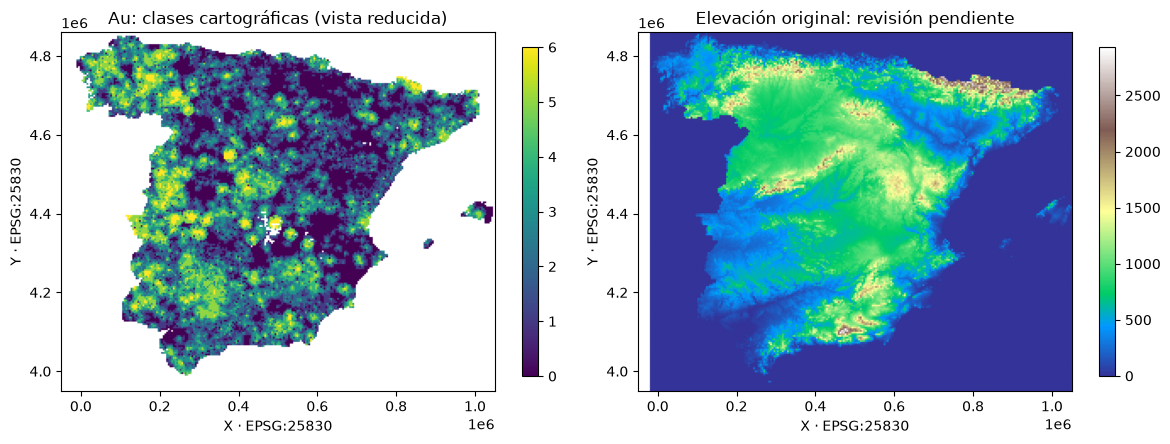

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, array, meta, title, cmap in [
    (axes[0], au_preview, au_meta, "Au: clases cartográficas (vista reducida)", "viridis"),
    (axes[1], mdt_preview, mdt_meta, "Elevación original: revisión pendiente", "terrain"),
]:
    left, bottom, right, top = meta["bounds"]
    artist = ax.imshow(array, extent=(left, right, bottom, top), origin="upper", cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel("X · EPSG:25830")
    ax.set_ylabel("Y · EPSG:25830")
    fig.colorbar(artist, ax=ax, shrink=.7)
plt.tight_layout()
plt.show()

In [17]:
shapefiles = [local_path(ROOT, item["path"]) for item in registros
              if item["format"] == ".shp" and item["status"] != "error"]
muestras_shp = {path.name: read_vector(path, max_features=5) for path in shapefiles}

#imprimir de la primera linea de cada shapefile, la variable geometry, pero que no se corte al mostrarla

print(muestras_shp["red-hidrografica2022-27_marzo2023.shp"].geometry.head())


0    LINESTRING (-7.2785 43.20963, -7.27854 43.20964, -7.27857 43.20965, -7.27861 43.20966,...
1    LINESTRING (-7.38503 43.26361, -7.38505 43.26363, -7.38507 43.26365, -7.38509 43.26368...
2    LINESTRING (-7.17598 42.93596, -7.17602 42.93596, -7.17611 42.93595, -7.17615 42.93594...
3    LINESTRING (-7.46896 42.57604, -7.46901 42.57586, -7.46902 42.57584, -7.46903 42.57582...
4    LINESTRING (-8.19339 42.15554, -8.19421 42.15515, -8.19504 42.15485, -8.19538 42.15479...
Name: geometry, dtype: geometry


## 10. Shapefile, respaldos y referencias QGIS

El shapefile se lee con sus componentes. El ZIP se inventaría sin extraerlo.
Los servicios remotos del QGZ se listan sin conectarse a ellos; una URL no se declara
disponible ni se interpreta como dato local. Un recuento igual entre SHP y GPKG no
demuestra equivalencia de geometrías: la conciliación espacial sigue pendiente.

In [18]:
shapefiles = [local_path(ROOT, item["path"]) for item in registros
              if item["format"] == ".shp" and item["status"] != "error"]
muestras_shp = {path.name: read_vector(path, max_features=5) for path in shapefiles}
for name, sample in muestras_shp.items():
    print(name, "CRS:", sample.crs)
    display(sample.head())
referencias_qgis = pd.DataFrame([ref for item in registros
                               for ref in item["details"].get("references", [])])
display(referencias_qgis)
if not referencias_qgis.empty:
    display(referencias_qgis[referencias_qgis.local_exists.eq(False)])

red-hidrografica2022-27_marzo2023.shp CRS: EPSG:4258


,thematicId,themaIdSch,hydroId,namespace,geonameTxt,geonamTxtL,continua,geometry
0,ES010MSPFES372MAR000010,euSurfaceWaterBodyCode,1,http://www.chminosil.es,Río Miño,spa,realSurfaceWaterSegment,"LINESTRING (-7.2785 43.20963, -7.27854 43.20964, -7.27857 43.20965, -7.27861 43.20966,..."
1,ES010MSPFES372MAR000052,euSurfaceWaterBodyCode,10,http://www.chminosil.es,Río Miño,spa,realSurfaceWaterSegment,"LINESTRING (-7.38503 43.26361, -7.38505 43.26363, -7.38507 43.26365, -7.38509 43.26368..."
2,ES010MSPFES393MAR000240,euSurfaceWaterBodyCode,100,http://www.chminosil.es,Río de Busto,spa,realSurfaceWaterSegment,"LINESTRING (-7.17598 42.93596, -7.17602 42.93596, -7.17611 42.93595, -7.17615 42.93594..."
3,ES010MSPFES464MAR001671,euSurfaceWaterBodyCode,100013406,http://www.chminosil.es,Río Mao,spa,realSurfaceWaterSegment,"LINESTRING (-7.46896 42.57604, -7.46901 42.57586, -7.46902 42.57584, -7.46903 42.57582..."
4,ES010MSPFES494MAR002260,euSurfaceWaterBodyCode,100013417,http://www.chminosil.es,Río Miño,spa,realSurfaceWaterSegment,"LINESTRING (-8.19339 42.15554, -8.19421 42.15515, -8.19504 42.15485, -8.19538 42.15479..."


,name,source,provider,remote,local_exists
0,AtlasGeoquimico_Au_Sedimentos_2012,./AtlasGeoquimico_Au_Sedimentos_2012.tif,gdal,False,True
1,Buzamientos,format='' layer='3' url='https://mapas.igme.es/gis/rest/services/Cartografia_Geologic...,arcgismapserver,True,None
2,ContactosFallasMagna50,./ContactosFallasMagna50.csv,ogr,False,True
3,ContactosGeode,./ContactosGeode.csv,ogr,False,True
4,Contactos,url='https://mapas.igme.es/gis/rest/services/Cartografia_Geologica/IGME_Geode_50/MapS...,arcgisfeatureserver,True,None
5,Contactos y fallas MAGNA 50,url='https://mapas.igme.es/gis/rest/services/Cartografia_Geologica/IGME_MAGNA_50/MapS...,arcgisfeatureserver,True,None
6,Cuaternario – Recintos,./Cuaternario – Recintos.csv,ogr,False,True
7,Cuaternario - Recintos,format='' layer='6' url='https://mapas.igme.es/gis/rest/services/Cartografia_Geologic...,arcgismapserver,True,None
8,Cuaternario - Recintos,url='https://mapas.igme.es/gis/rest/services/Cartografia_Geologica/IGME_Geode_50/MapS...,arcgisfeatureserver,True,None
9,Edades 1M,url='https://mapas.igme.es/gis/rest/services/Cartografia_Geologica/IGME_Edades_1M/Map...,arcgisfeatureserver,True,None


,name,source,provider,remote,local_exists
28,bdmin_au_clean,./data/processed/bdmin_au_clean.gpkg|layername=bdmin_au_clean,ogr,False,False


## 11. Guardar manifiesto, configuración, entorno y pendientes

Cada ejecución crea un directorio nuevo. `manifest.json` guarda los hashes, capas,
bandas, muestras y problemas; `catalogo.csv` permite revisar el resultado en Excel.
`environment.freeze.txt` registra las versiones realmente instaladas, incluidas las
dependencias transitivas; no promete compatibilidad con otro sistema operativo.

El manifiesto registra tanto archivos canónicos como derivados y componentes del SHP.
Sus hashes permiten detectar cambios, pero no prueban autenticidad del organismo productor.

In [19]:
RUN_DIR = write_reports(ROOT, CONFIG, registros)
write_json(RUN_DIR / "resumen_indicios.json", resumen_indicios.to_dict("records"))
bandas.to_csv(RUN_DIR / "bandas_raster.csv", index=False, encoding="utf-8-sig")
canonicas.to_csv(RUN_DIR / "fuentes_canonicas.csv", index=False, encoding="utf-8-sig")
fig.savefig(RUN_DIR / "vista_previa_rasters.png", dpi=130, bbox_inches="tight")
print("Resultados:", RUN_DIR)
display(pd.read_json(RUN_DIR / "pendientes.json"))

Resultados: C:\Users\Lenovo\Desktop\PROYECTO IA\Proyecto Con Luis\reports\fase_a\20260907T084628_766569Z


,name,reason,priority
0,mascara_terrestre_oficial,No se ha identificado una máscara territorial canónica local.,imprescindible antes de crear rejilla
1,leyendas_geologicas_validadas,Verificar diccionarios y equivalencias de unidades y estructuras.,imprescindible antes de derivar variables
2,mdt25.tif,No figura en el inventario inicial; necesario valorar para detalle aluvial.,ampliación aluvial
3,geoquimica_analitica_original,Los TIFF actuales proceden de simbología por intervalos.,mejora posterior
4,buzamientos.gpkg,sin_datos,revisar por familia
5,cuaternariorecintos.gpkg,sin_datos,revisar por familia
6,gravimetria.gpkg,sin_datos,revisar por familia
7,magnetometriaradiometria.gpkg,sin_datos,revisar por familia
8,magnetotelurico.gpkg,sin_datos,revisar por familia
9,MDT_CNIG_Elevacion_Hillshade_RGB.tif.aux.xml,auxiliar_sin_raster,revisar por familia


## 12. Control de cierre y contrato para el siguiente notebook

Se vuelven a verificar tamaño, fecha y SHA-256 de las fuentes: la fase A no debe
modificarlas. Un error de lectura queda documentado y detiene el cierre. Los GPKG
vacíos y fuentes ausentes son carencias de datos, no se ocultan ni se consideran
pruebas fallidas del lector.

El siguiente notebook consumirá el manifiesto y la configuración, volverá a abrir
las rutas canónicas y comenzará la conciliación y limpieza. No necesita que este
kernel permanezca abierto ni que se serialicen objetos Python inseguros.

In [20]:
cambios = verify_unchanged(ROOT, registros, rehash=CONFIG["inspection"]["compute_sha256"])
control = {
    "fuentes_inspeccionadas": len(registros),
    "errores_lectura": len(errores_lectura),
    "fuentes_sin_datos": int(catalogo.status.eq("sin_datos").sum()),
    "fuentes_modificadas": cambios,
    "hashes_completos": all(item["sha256"] for item in registros),
    "estado": "carga_local_completada" if not cambios and errores_lectura.empty else "requiere_resolver_errores",
    "limpieza_geologica_realizada": False,
    "datos_remotos_descargados": False,
}
write_json(RUN_DIR / "control_cierre.json", control)
display(pd.Series(control, dtype=object).to_frame("resultado"))
assert not cambios, "Las fuentes cambiaron durante la ejecución; revisar antes de continuar."
assert errores_lectura.empty, f"Hay {len(errores_lectura)} errores. Consulta manifest.json."
print("Carga local finalizada. Fuentes disponibles en `fuentes`, `vectores`, `tablas` y `rasters`.")
print("Siguiente tarea: conciliar indicios y revisar sus coordenadas y etiquetas.")

,resultado
fuentes_inspeccionadas,93
errores_lectura,0
fuentes_sin_datos,9
fuentes_modificadas,[]
hashes_completos,True
estado,carga_local_completada
limpieza_geologica_realizada,False
datos_remotos_descargados,False


Carga local finalizada. Fuentes disponibles en `fuentes`, `vectores`, `tablas` y `rasters`.
Siguiente tarea: conciliar indicios y revisar sus coordenadas y etiquetas.


**Notas de diseño y referencias:**

- Los límites de lectura, filtros por `bbox` y lectura de atributos usan la API
  documentada de [Pyogrio](https://pyogrio.readthedocs.io/en/latest/introduction.html).
- Las ventanas preservan la transformada del recorte siguiendo
  [Rasterio](https://rasterio.readthedocs.io/en/stable/topics/windowed-rw.html).
- No se calculan features predictoras, métricas ML ni una cobertura española certificada
  a partir de estas vistas. Esas decisiones permanecen en las fases siguientes del plan.